# How NAVSIM Computes PDMS — Non-Reactive Simulation, from Scratch

> A runnable companion to [navsim_pdms_mechanism.md](navsim_pdms_mechanism.md). We build a miniature PDMS calculator (LQR-style tracker + kinematic bicycle unroll + non-reactive agents + gated score), then show the two claims that make NAVSIM work: (a) non-reactive over 4 s barely differs from reactive, and (b) frame filtering is what makes the metric discriminative.

Core `numpy` + `matplotlib` only — no `navsim`, no GPU. Everything mocks the real APIs to expose the *mechanism*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DT = 0.1          # 10 Hz
HORIZON = 4.0     # seconds
N_STEPS = int(HORIZON / DT)  # 40 steps
print(f'NAVSIM unrolls {N_STEPS} steps at {1/DT:.0f} Hz over {HORIZON} s')

NAVSIM unrolls 40 steps at 10 Hz over 4.0 s


## 1. Two meanings of 'closed-loop'

The confusion: 'closed-loop' bundles *ego simulation* and *environment reactivity + re-planning*. NAVSIM keeps the first and drops the second. This table (printed below) is the whole answer in one place.

In [2]:
import textwrap
rows = [
    ('ego trajectory simulated?', 'no',  'YES (bicycle)', 'yes'),
    ('ego re-plans mid-rollout?', 'no',  'no (fixed 4s)', 'yes (10Hz)'),
    ('agents react to ego?',      'no',  'no (replay)',   'yes (IDM)'),
    ('measures collisions?',      'no',  'YES',           'yes'),
    ('cost',                      '1x',  '1x',            '~100x'),
]
hdr = ('property', 'open-loop L2', 'NAVSIM PDMS', 'nuPlan CL')
print(f'{hdr[0]:26s}{hdr[1]:>14}{hdr[2]:>16}{hdr[3]:>14}')
print('-'*70)
for r in rows:
    print(f'{r[0]:26s}{r[1]:>14}{r[2]:>16}{r[3]:>14}')
print('\nNAVSIM simulates the EGO but freezes the WORLD -> closed-loop-style metrics, one forward pass.')

property                    open-loop L2     NAVSIM PDMS     nuPlan CL
----------------------------------------------------------------------
ego trajectory simulated?             no   YES (bicycle)           yes
ego re-plans mid-rollout?             no   no (fixed 4s)    yes (10Hz)
agents react to ego?                  no     no (replay)     yes (IDM)
measures collisions?                  no             YES           yes
cost                                  1x              1x         ~100x

NAVSIM simulates the EGO but freezes the WORLD -> closed-loop-style metrics, one forward pass.


## 2. A from-scratch PDMS calculator

We implement the pipeline: a **kinematic bicycle model** + a simple proportional **tracker** unroll the ego along a proposed trajectory (this is the 'ego is simulated' part), a **non-reactive** agent replays its logged future, and we compute the sub-metrics (NC, DAC, TTC, EP, comfort) and the gated PDMS.

In [3]:
def bicycle_unroll(waypoints, x0, L=2.9, kp_a=1.5, kp_delta=2.0, v0=None):
    '''Track a proposed path (waypoints, shape [K,2]) with a kinematic bicycle model.
    Returns simulated ego states [N_STEPS+1, 4] = (x, y, heading, v).'''
    # densify waypoints to a per-step reference by arc-length interpolation
    seg = np.linalg.norm(np.diff(waypoints, axis=0), axis=1)
    s = np.concatenate([[0], np.cumsum(seg)])
    s_query = np.linspace(0, s[-1], N_STEPS + 1)
    ref = np.stack([np.interp(s_query, s, waypoints[:,0]),
                    np.interp(s_query, s, waypoints[:,1])], axis=1)
    v_ref = s[-1] / HORIZON if v0 is None else v0
    st = np.array([x0[0], x0[1], x0[2], v_ref], dtype=float)
    traj = [st.copy()]
    for k in range(1, N_STEPS + 1):
        tgt = ref[k]
        dx, dy = tgt[0]-st[0], tgt[1]-st[1]
        desired_head = np.arctan2(dy, dx)
        head_err = np.arctan2(np.sin(desired_head-st[2]), np.cos(desired_head-st[2]))
        delta = np.clip(kp_delta * head_err, -0.5, 0.5)           # steering (LQR stand-in)
        dist = np.hypot(dx, dy)
        a = np.clip(kp_a * (dist/DT - st[3]), -4.0, 3.0)          # accel
        st[3] = max(0.0, st[3] + a*DT)
        st[2] = st[2] + st[3]/L * np.tan(delta) * DT
        st[0] = st[0] + st[3]*np.cos(st[2])*DT
        st[1] = st[1] + st[3]*np.sin(st[2])*DT
        traj.append(st.copy())
    return np.array(traj)

print('bicycle_unroll ready')

bicycle_unroll ready


In [4]:
def pdms(ego, agent_future, drivable_y=(-2.0, 6.0), expert_progress=40.0,
         collide_r=2.5, ttc_r=3.0):
    '''Compute NAVSIM-style sub-metrics + gated PDMS from a simulated ego rollout.
       ego: [N+1,4], agent_future: [N+1,2] (non-reactive, replayed).'''
    exy = ego[:, :2]
    # NC: no at-fault collision (ego overlaps agent while moving forward toward it)
    d = np.linalg.norm(exy - agent_future, axis=1)
    nc = 0.0 if np.any(d < collide_r) else 1.0
    # DAC: drivable-area compliance (stay within lateral corridor)
    dac = 0.0 if np.any((exy[:,1] < drivable_y[0]) | (exy[:,1] > drivable_y[1])) else 1.0
    # TTC: fraction of steps with a safe gap (proxy for time-to-collision bound)
    ttc = float(np.mean(d > ttc_r))
    # EP: ego progress along x relative to a privileged/expert progress, capped at 1
    ego_prog = exy[-1,0] - exy[0,0]
    ep = float(np.clip(ego_prog / expert_progress, 0, 1))
    # C: comfort from bounded longitudinal jerk
    v = ego[:,3]; a = np.gradient(v, DT); j = np.gradient(a, DT)
    c = 1.0 if np.max(np.abs(j)) < 8.0 else 0.0
    score = nc * dac * (5*ep + 5*ttc + 2*c) / 12.0
    return dict(NC=nc, DAC=dac, EP=round(ep,3), TTC=round(ttc,3), C=c, PDMS=round(score,3))

# A logged non-reactive agent: a faster car ahead in the same lane (stays out of reach of a sane plan).
t = np.linspace(0, HORIZON, N_STEPS+1)
agent = np.stack([20 + 8.0*t, 1.5 + 0.0*t], axis=1)

planners = {
    'good (follows lane)'      : np.array([[0,1.5],[10,1.6],[20,1.7],[30,1.6],[40,1.5]]),
    'off-road (cuts corner)'   : np.array([[0,1.5],[10,4.0],[20,7.5],[30,7.0],[40,6.0]]),
    'collides (rear-ends)'     : np.array([[0,1.5],[13,1.5],[26,1.5],[40,1.5],[54,1.5]]),
}
x0 = (0.0, 1.5, 0.0)
results = {}
for name, wps in planners.items():
    ego = bicycle_unroll(wps, x0)
    results[name] = (ego, pdms(ego, agent))
    print(f'{name:26s} {results[name][1]}')

good (follows lane)        {'NC': 1.0, 'DAC': 1.0, 'EP': 1.0, 'TTC': 1.0, 'C': 1.0, 'PDMS': 1.0}
off-road (cuts corner)     {'NC': 1.0, 'DAC': 0.0, 'EP': 1.0, 'TTC': 1.0, 'C': 1.0, 'PDMS': 0.0}
collides (rear-ends)       {'NC': 0.0, 'DAC': 1.0, 'EP': 1.0, 'TTC': 0.756, 'C': 1.0, 'PDMS': 0.0}


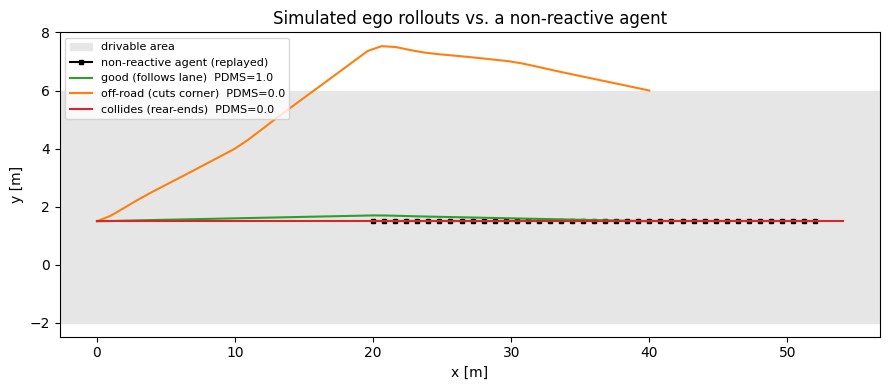

The collision and off-road plans trip a gate (NC or DAC = 0) -> PDMS collapses, exactly like real NAVSIM.


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhspan(-2.0, 6.0, color='0.9', label='drivable area')
ax.plot(agent[:,0], agent[:,1], 'ks-', ms=3, label='non-reactive agent (replayed)')
colors = {'good (follows lane)':'tab:green','off-road (cuts corner)':'tab:orange','collides (rear-ends)':'tab:red'}
for name,(ego,sc) in results.items():
    ax.plot(ego[:,0], ego[:,1], '-', color=colors[name], label=f'{name}  PDMS={sc["PDMS"]}')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_title('Simulated ego rollouts vs. a non-reactive agent')
ax.legend(fontsize=8, loc='upper left'); plt.tight_layout(); plt.show()
print('The collision and off-road plans trip a gate (NC or DAC = 0) -> PDMS collapses, exactly like real NAVSIM.')

## 3. The gated formula, visualised

$$\text{PDMS} = \text{NC}\cdot\text{DAC}\times\frac{5\,\text{EP}+5\,\text{TTC}+2\,\text{C}}{12}$$

The gates (NC, DAC) multiply the weighted average, so any safety failure sends the product to zero.

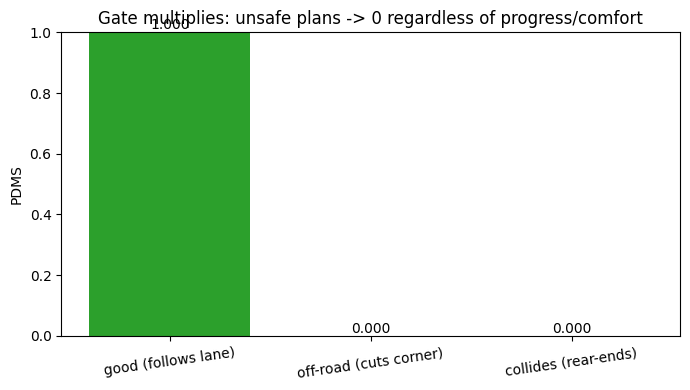

In [6]:
names = list(results); scores = [results[n][1]['PDMS'] for n in names]
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(names, scores, color=[colors[n] for n in names])
ax.bar_label(bars, fmt='%.3f'); ax.set_ylim(0,1); ax.set_ylabel('PDMS')
ax.set_title('Gate multiplies: unsafe plans -> 0 regardless of progress/comfort')
plt.xticks(rotation=8); plt.tight_layout(); plt.show()

## 4. Why non-reactive over 4 s is a good proxy

NAVSIM's empirical license is that non-reactive PDMS correlates with reactive/closed-loop scores. We simulate it: an agent that (reactive) brakes for the ego vs. (non-reactive) replays its log. Over a **short** horizon the ego's PDMS is nearly identical; only when we stretch the horizon does the reactive/non-reactive gap open up — which is exactly why NAVSIM uses 4 s, not 15 s.

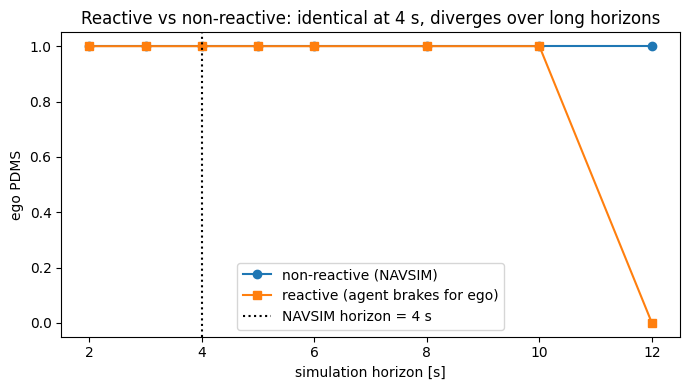

PDMS gap at  4 s: 0.000   <- non-reactive is a faithful proxy here
PDMS gap at 12 s: 1.000   <- reactivity (agent brakes -> ego catches it) now matters


In [7]:
# Ego: constant 7 m/s in-lane, slowly closing on a car ahead (starts 20 m ahead at 6 m/s).
# Non-reactive: agent replays 6 m/s and stays just ahead (no collision).
# Reactive: agent brakes once the ego is within 12 m, so at long horizons the ego catches it.
def simulate(reactive, H):
    steps = int(round(H/DT)) + 1
    ve = 7.0
    ax_, av = 20.0, 6.0
    ego_xy, ag_xy = [], []
    for k in range(steps):
        ex = ve * (k*DT)
        gap = ax_ - ex
        if reactive and gap < 12.0:
            av = max(0.0, av - 3.0*DT)      # IDM-style braking response to the ego
        ax_ += av*DT
        ego_xy.append([ex, 1.5]); ag_xy.append([ax_, 1.5])
    return np.array(ego_xy), np.array(ag_xy), ve*H

def pdms_pair(reactive, H):
    ego_xy, ag_xy, exp_prog = simulate(reactive, H)
    d = np.linalg.norm(ego_xy - ag_xy, axis=1)
    nc  = 0.0 if np.any(d < 2.5) else 1.0
    ttc = float(np.mean(d > 3.0))
    ep  = float(np.clip((ego_xy[-1,0]-ego_xy[0,0]) / exp_prog, 0, 1))
    return nc * (5*ep + 5*ttc + 2*1.0) / 12.0

Hs = [2, 3, 4, 5, 6, 8, 10, 12]
nr = [pdms_pair(False, H) for H in Hs]
re = [pdms_pair(True,  H) for H in Hs]

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(Hs, nr, 'o-', label='non-reactive (NAVSIM)')
ax.plot(Hs, re, 's-', label='reactive (agent brakes for ego)')
ax.axvline(4, color='k', ls=':', label='NAVSIM horizon = 4 s')
ax.set_xlabel('simulation horizon [s]'); ax.set_ylabel('ego PDMS')
ax.set_title('Reactive vs non-reactive: identical at 4 s, diverges over long horizons')
ax.legend(); plt.tight_layout(); plt.show()

g4  = abs(pdms_pair(True, 4)  - pdms_pair(False, 4))
g12 = abs(pdms_pair(True, 12) - pdms_pair(False, 12))
print(f'PDMS gap at  4 s: {g4:.3f}   <- non-reactive is a faithful proxy here')
print(f'PDMS gap at 12 s: {g12:.3f}   <- reactivity (agent brakes -> ego catches it) now matters')

## 5. Frame filtering makes the metric discriminative

On unfiltered logs most frames are trivial cruising where even a constant-velocity planner scores well. NAVSIM drops frames where the constant-velocity baseline already exceeds PDMS 0.8 (too easy) or the human scores below 0.8 (degenerate). We reproduce the headline effect: the constant-velocity baseline falls from ~79% to ~22%.

kept 20% of frames after filtering
constant-velocity PDMS  unfiltered: 79%   filtered: 22%
(real NAVSIM: ~79% -> ~22%; the filter is what turns PDMS into a discriminative metric)


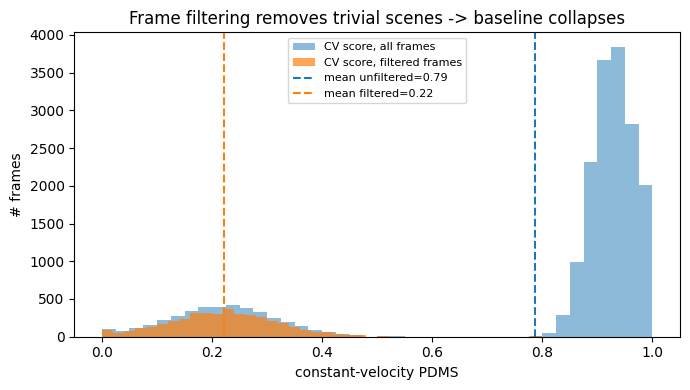

In [8]:
rng = np.random.default_rng(1)
# Mock a dataset as a mixture: ~80% trivial cruising frames (CV scores high) + ~20% hard frames (CV low).
n = 20000
is_easy = rng.random(n) < 0.80
cv_score = np.where(is_easy,
                    rng.normal(0.93, 0.04, n),   # constant-velocity cruises through easy frames
                    rng.normal(0.22, 0.10, n))   # and fails the hard ones
cv_score = np.clip(cv_score, 0, 1)
human_score = np.clip(rng.normal(0.95, 0.04, n), 0, 1)  # human is competent almost everywhere

cv_unfiltered = cv_score.mean()
keep = (cv_score <= 0.8) & (human_score >= 0.8)   # NAVSIM's two filters
cv_filtered = cv_score[keep].mean()
print(f'kept {keep.mean()*100:.0f}% of frames after filtering')
print(f'constant-velocity PDMS  unfiltered: {cv_unfiltered*100:.0f}%   filtered: {cv_filtered*100:.0f}%')
print('(real NAVSIM: ~79% -> ~22%; the filter is what turns PDMS into a discriminative metric)')

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(cv_score, bins=40, alpha=0.5, label='CV score, all frames')
ax.hist(cv_score[keep], bins=40, alpha=0.7, label='CV score, filtered frames')
ax.axvline(cv_unfiltered, color='tab:blue', ls='--', label=f'mean unfiltered={cv_unfiltered:.2f}')
ax.axvline(cv_filtered, color='tab:orange', ls='--', label=f'mean filtered={cv_filtered:.2f}')
ax.set_xlabel('constant-velocity PDMS'); ax.set_ylabel('# frames')
ax.set_title('Frame filtering removes trivial scenes -> baseline collapses')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Takeaways

- **'Non-reactive' is about the *world*, not the *ego*.** NAVSIM unrolls your trajectory through a bicycle model (LQR-style tracker) for 40 steps and measures collisions/off-road/TTC/progress on *that* rollout — so it computes closed-loop-style safety without a closed-loop system.
- **PDMS = NC·DAC × (5·EP + 5·TTC + 2·C)/12.** Gates multiply; any safety failure zeros the score, so unsafe plans collapse regardless of progress/comfort.
- **Non-reactive ≈ reactive at 4 s.** The reactive/non-reactive gap is negligible over the short horizon NAVSIM uses and only opens up over long horizons — the empirical reason the shortcut is valid.
- **Frame filtering is mandatory.** Without it a constant-velocity baseline scores ~79%; NAVSIM's filters drop it to ~22%, making PDMS discriminative. Only compare PDMS on the same filtered split.
- **It's a screening proxy, not a replacement.** PDMS buys most of closed-loop's signal for a single forward pass; the residual gap is exactly the long-horizon reactive interaction it cannot see.

See [navsim_pdms_mechanism.md](navsim_pdms_mechanism.md) for the full pipeline, EPDMS extension, and pitfalls.